In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
pi = np.pi

Error function $F(\omega_0, \gamma)$

In [14]:
omega_A = 10*pi
Gamma = 5*pi
ir = 0*pi
uv = 23*pi
n = 1

def F(omega_0_guess, gamma_guess):
    #Store the alpha coeffcients
    polynom_tab = np.zeros(n+1, dtype=complex)

    polynom_tab[0] = -gamma_guess/2 + 1j*gamma_guess/(2*pi)*np.log((uv-omega_0_guess)/(omega_0_guess - ir))

    for i in range(1, n+1):
        polynom_tab[i] = (-1j)**(i-1) * gamma_guess / (2*i*pi) * \
                    ((omega_0_guess - ir)**(-i) + (-1)**(i-1) * (uv - omega_0_guess)**(-i)) \
                    * (1j* (omega_0_guess - omega_A) - Gamma/2)**i

    error_term = np.sum(polynom_tab) - (1j* (omega_0_guess - omega_A) - Gamma/2)

    return error_term

def F_real(vars):
    omega_0, gamma = vars
    val = F(omega_0, gamma)
    return [val.real, val.imag]

# Solveur
initial_guess = (omega_A, Gamma)
#initial_guess = (0.8*uv, 1.5*Gamma)
sol = root(F_real, initial_guess)
omega_0, gamma = sol.x
print(f"omega_0_n = {omega_0:.5f}, gamma_n = {gamma:.5f} \n --------------")
print(f"omega_A = {omega_A:.5f}, Gamma = {Gamma:.5f}")

omega_0_n = 31.99103, gamma_n = 13.77608 
 --------------
omega_A = 31.41593, Gamma = 15.70796


Heat map of $|F(\omega_0, \gamma)|$

Solution found: [31.99103131 13.77607969]


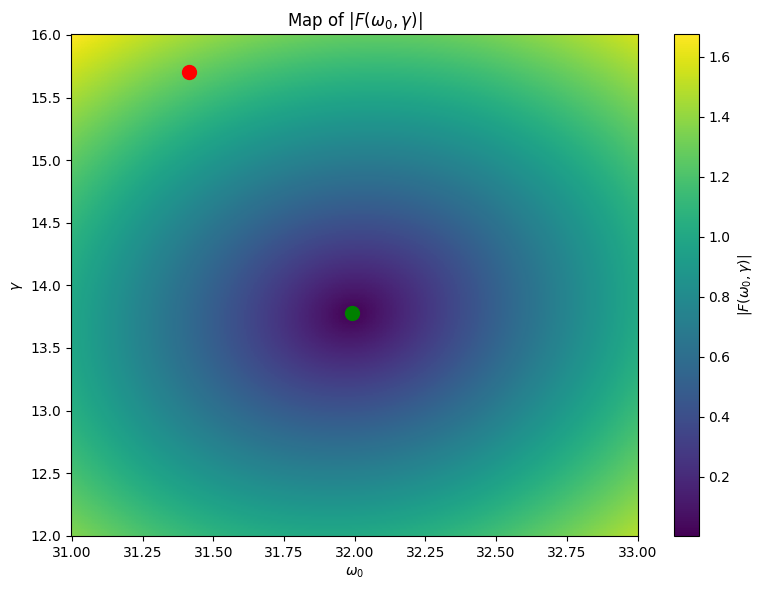

In [ ]:
# Domaine
w_inf = 0.5*ir + 0.5*omega_A
w_sup = 0.5*uv + 0.5*omega_A
g_inf = 0
g_sup = 1.1*Gamma

omega_vals = np.linspace(w_inf, w_sup, 400)
gamma_vals = np.linspace(g_inf, g_sup, 400)

Omega, Gamma_grid = np.meshgrid(omega_vals, gamma_vals)

# Calcul de |F|
Z = np.zeros_like(Omega, dtype=float)

for i in range(Omega.shape[0]):
    for j in range(Omega.shape[1]):
        Z[i, j] = np.abs(F(Omega[i, j], Gamma_grid[i, j]))

# Plot 2D
plt.figure(figsize=(8,6))
plt.pcolormesh(Omega, Gamma_grid, Z, shading='auto')
plt.colorbar(label=r'$|F(\omega_0, \gamma)|$')

#Add a marker of the physical parameters in the plane
plt.scatter(omega_A, Gamma, color='red', s=100, label=r'Physical parameters $(\omega_A, \Gamma)$')

# Affichage
if sol.success:
    plt.scatter(sol.x[0], sol.x[1],
                color='green', s=100,
                label=r'Root found by solver')
    print("Solution found:", sol.x)
else:
    print("Root finding failed.")

plt.xlabel(r'$\omega_0$')
plt.ylabel(r'$\gamma$')
plt.title(r'Map of $|F(\omega_0, \gamma)|$')
plt.tight_layout()
plt.show()